In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(150, 6)

In [10]:
df.value_counts("Species")

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

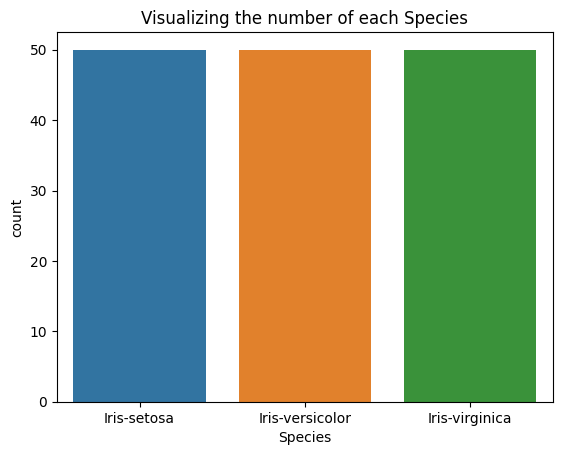

In [11]:
sns.countplot(x="Species", data=df, hue="Species")
plt.title("Visualizing the number of each Species")
plt.show

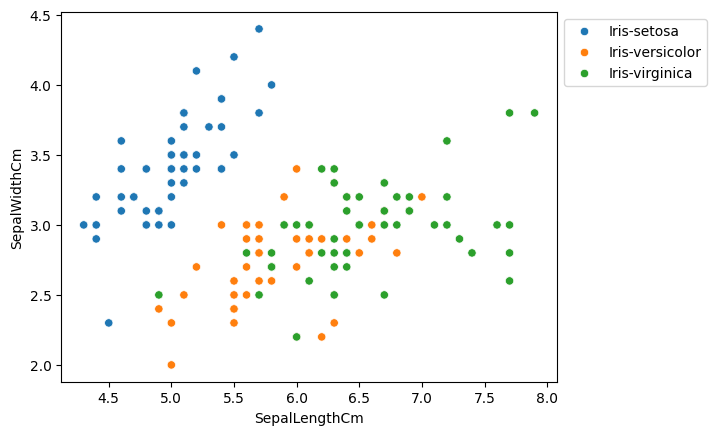

In [12]:
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df)
plt.legend(bbox_to_anchor=(1, 1), loc=2)
plt.show()

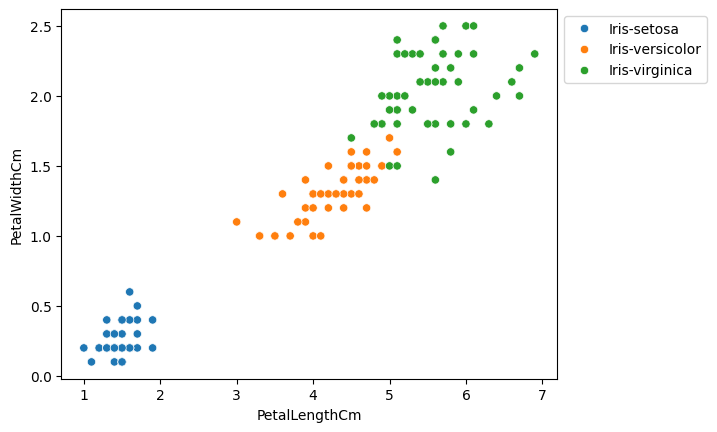

In [13]:
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df)
plt.legend(bbox_to_anchor=(1, 1), loc=2)
plt.show()

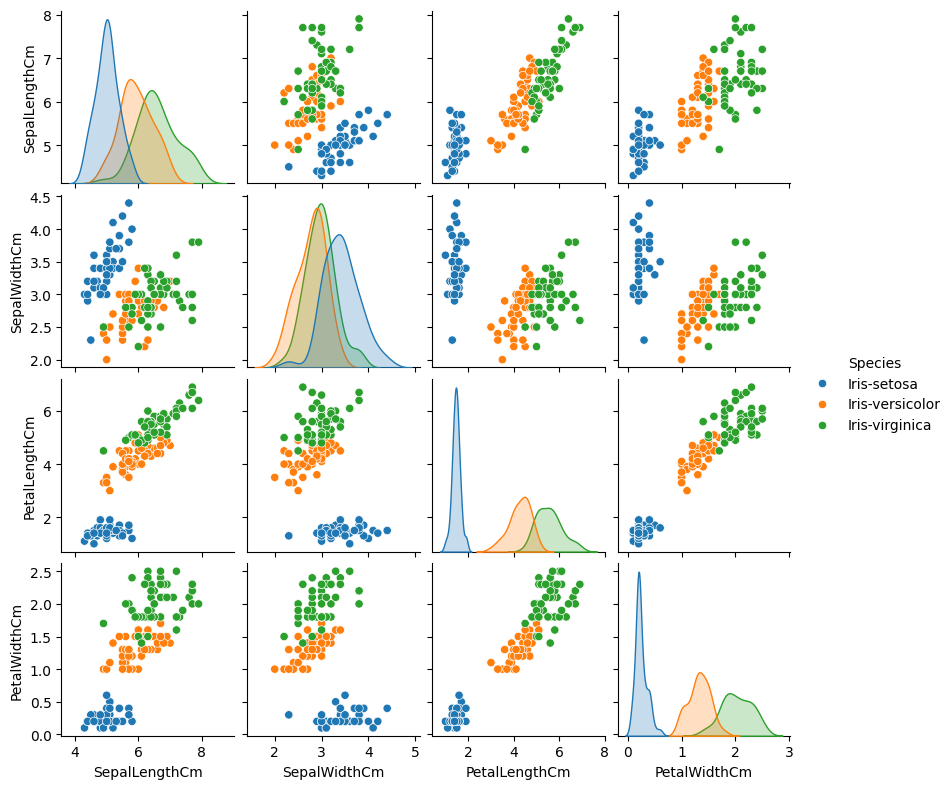

In [14]:
sns.pairplot(df.drop(['Id'], axis=1), hue='Species', height=2)

In [15]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

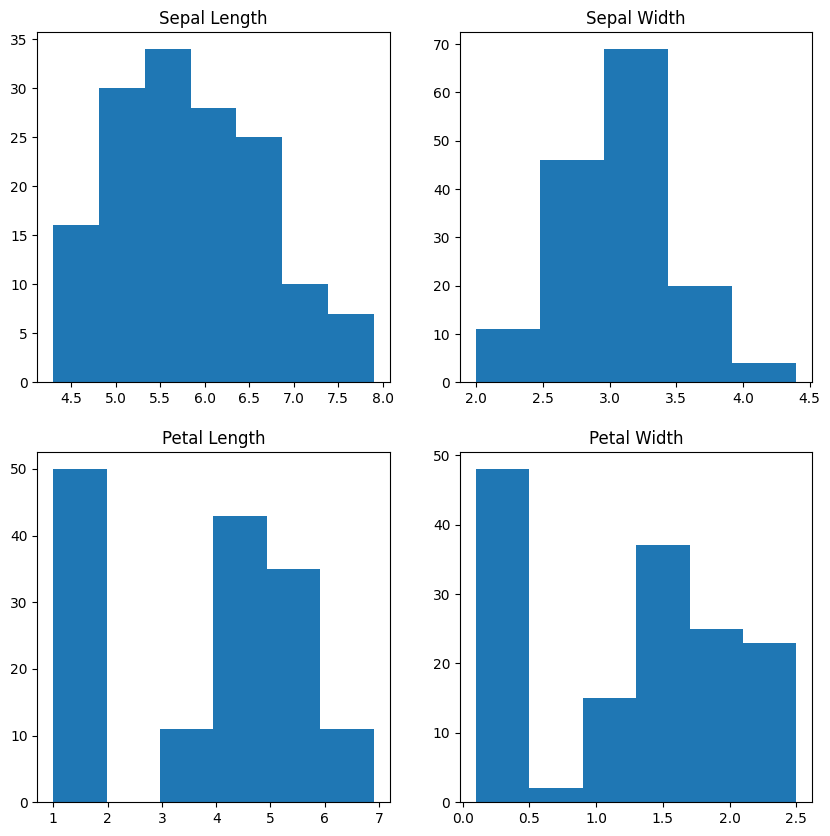

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0, 0].set_title("Sepal Length")
axes[0, 0].hist(df['SepalLengthCm'], bins=7)

axes[0, 1].set_title("Sepal Width")
axes[0, 1].hist(df['SepalWidthCm'], bins=5)

axes[1, 0].set_title("Petal Length")
axes[1, 0].hist(df['PetalLengthCm'], bins=6)

axes[1, 1].set_title("Petal Width")
axes[1, 1].hist(df['PetalWidthCm'], bins=6)

plt.show()

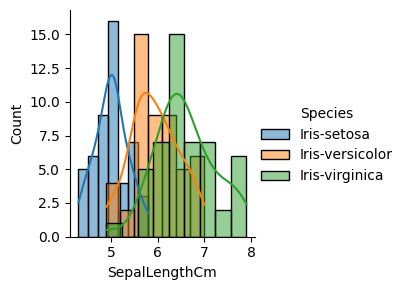

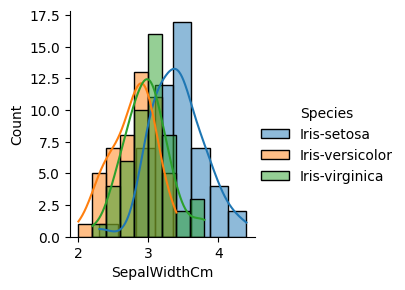

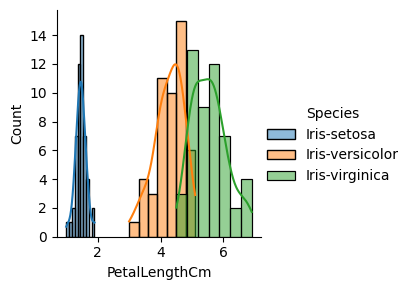

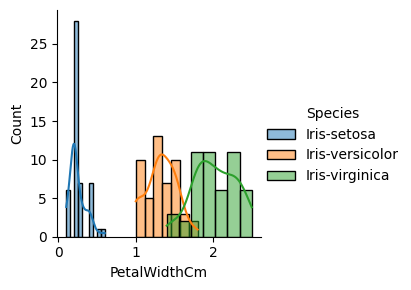

In [17]:
plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.histplot, "SepalLengthCm", kde=True).add_legend()

plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.histplot, "SepalWidthCm", kde=True).add_legend()

plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.histplot, "PetalLengthCm", kde=True).add_legend()

plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.histplot, "PetalWidthCm", kde=True).add_legend()

plt.show()

In [18]:
df.select_dtypes(include=['number']).corr()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,1.000000,0.716676,-0.397729,0.882747,0.899759
SepalLengthCm,0.716676,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.397729,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.882747,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.899759,0.817954,-0.356544,0.962757,1.000000


In [19]:
df.select_dtypes(include=['number']).corr(method='pearson').drop(['Id'], axis=1).drop(['Id'], axis=0)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


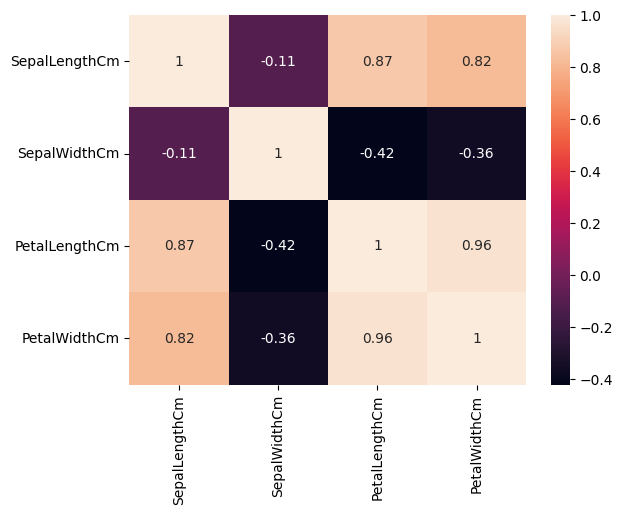

In [20]:
sns.heatmap(df.select_dtypes(include=['number']).corr().drop(['Id'], axis=1).drop(['Id'], axis=0), annot=True)
plt.show()

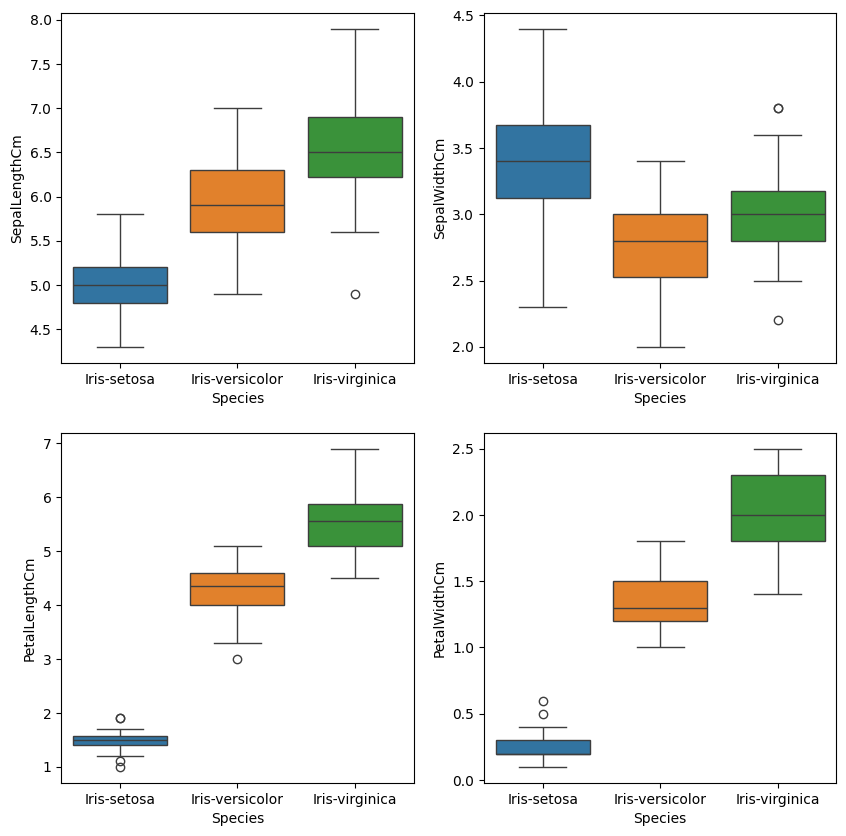

In [21]:
def graph(y):
    sns.boxplot(x="Species", y=y, data=df, hue="Species")

plt.figure(figsize=(10, 10))

plt.subplot(221)
graph("SepalLengthCm")

plt.subplot(222)
graph("SepalWidthCm")

plt.subplot(223)
graph("PetalLengthCm")

plt.subplot(224)
graph("PetalWidthCm")

plt.show()

# Handling Outliers

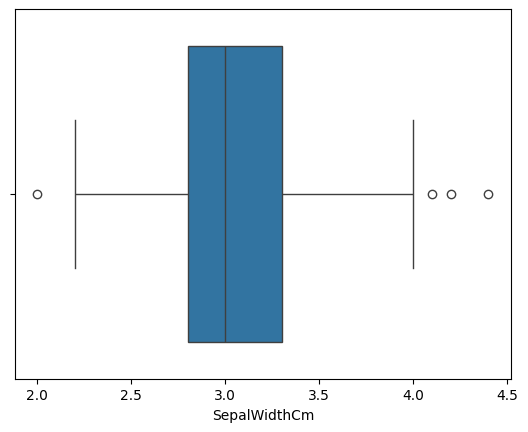

In [22]:
sns.boxplot(x="SepalWidthCm", data=df)
plt.show()

## Removing Outliers

Old Shape: (150, 6)
New Shape: (146, 6)


<Axes: xlabel='SepalWidthCm'>

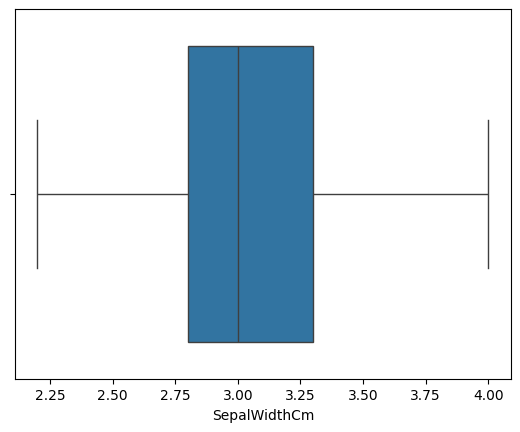

In [23]:
Q1 = np.percentile(df['SepalWidthCm'], 25, interpolation = 'midpoint')

Q3 = np.percentile(df['SepalWidthCm'], 75, interpolation = 'midpoint')

IQR = Q3 - Q1

print(f"Old Shape: {df.shape}")

# Upper Bound
upper = np.where(df['SepalWidthCm'] >= (Q3+1.5*IQR))

# Lower Bound
lower = np.where(df['SepalWidthCm'] <= Q1-1.5*IQR)

# Removing Outliers
df.drop(upper[0], inplace=True)
df.drop(lower[0], inplace=True)

print(f"New Shape: {df.shape}")

sns.boxplot(x='SepalWidthCm', data=df)

## Decision Trees

In [24]:
df.head()
X = df.drop(["Species", "Id"], axis=1)
y = df["Species"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
decision_tree = DecisionTreeClassifier()

In [27]:
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.88      0.88      0.88         8
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.92      0.92      0.92        30
   weighted avg       0.93      0.93      0.93        30



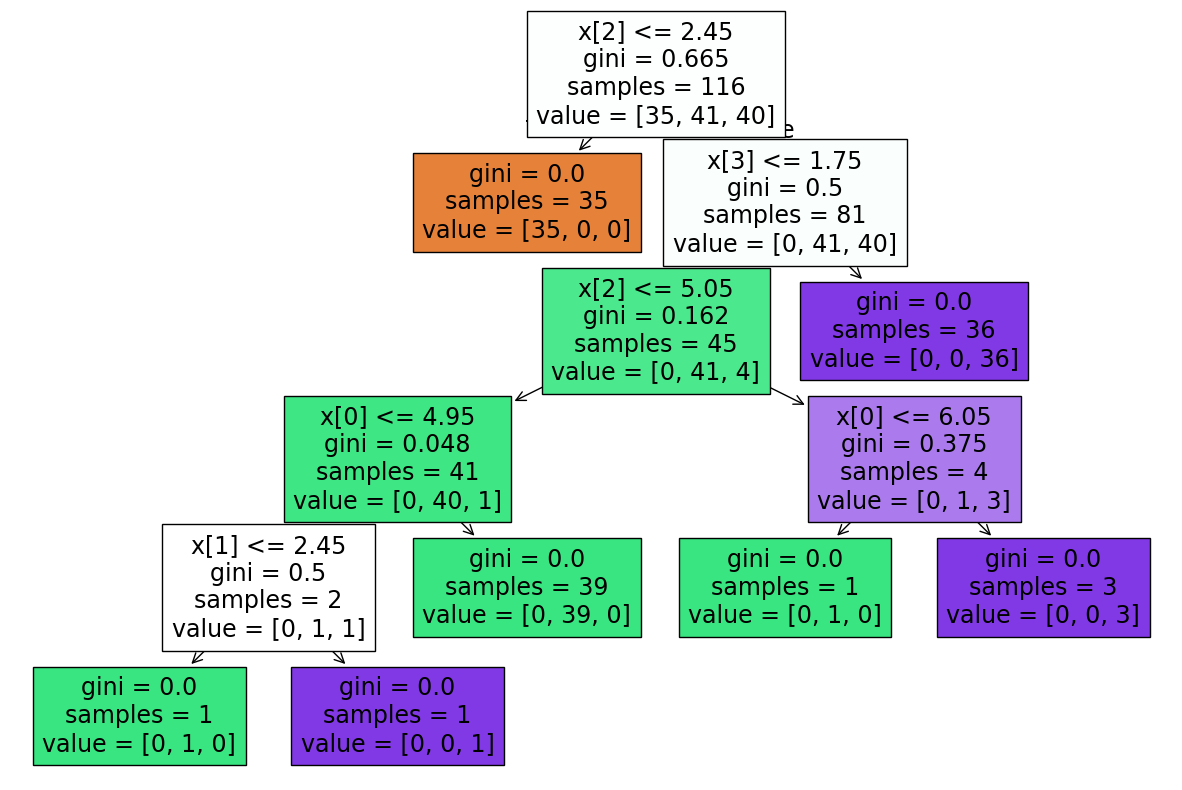

In [28]:
plt.figure(figsize=(15, 10))
plot_tree(decision_tree, filled=True)
ypred = decision_tree.predict(X_test)
score = accuracy_score(ypred, y_test)
print(score)
print(classification_report(ypred, y_test))

# Random Forest Classifier

In [29]:
rfc = RandomForestClassifier()

In [30]:
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
rfc_ypred = rfc.predict(X_test)
score = accuracy_score(rfc_ypred, y_test)
print(score)
print(classification_report(rfc_ypred, y_test))

0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.88      0.88      0.88         8
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.92      0.92      0.92        30
   weighted avg       0.93      0.93      0.93        30



In [32]:
svm_model = svm.SVC(kernel='linear')

In [33]:
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [34]:
svm_model_ypred = rfc.predict(X_test)
score_svm = accuracy_score(svm_model_ypred, y_test)
print(score)
print(classification_report(svm_model_ypred, y_test))

0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.88      0.88      0.88         8
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.92      0.92      0.92        30
   weighted avg       0.93      0.93      0.93        30



## Model Comparison Summary

| Model                  | Accuracy | Precision (avg) | Recall (avg) | F1-score (avg) |
|-------------------------|-----------|-----------------|---------------|----------------|
| Decision Tree           | 93.33%    | 0.92            | 0.92          | 0.92           |
| Random Forest           | 93.33%    | 0.92            | 0.92          | 0.92           |
| Support Vector Machine  | 93.33%    | 0.92            | 0.92          | 0.92           |

### Conclusion
All three models: Decision Tree, Random Forest, and Support Vector Machine, achieved the same accuracy of **93.33%** on the Iris dataset, with nearly identical precision, recall, and F1-scores.  
This indicates that the dataset is well-structured and relatively easy to classify. While all models perform equally here, in more complex or noisy datasets, **Random Forests and SVMs** generally offer better generalization compared to a single Decision Tree.